#Working with HTTP APIs in Python

##The requests Library

The requests library helps Python send HTTP requests easily.



In [1]:
import requests

# Send a GET request to an API
response = requests.get("https://jsonplaceholder.typicode.com/posts/1")

# Convert response into JSON data
data = response.json()

# Print the data
print(data)

{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}


##HTTP Verbs, Headers, Status Codes

These are the “rules of communication” in APIs.

###HTTP Verbs

HTTP verbs tell the server what action you want.

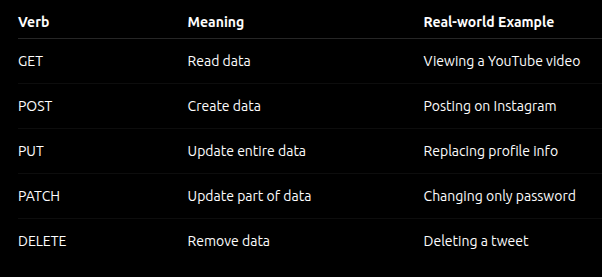

In [2]:
import requests

# Data to send
new_post = {
    "title": "Learning APIs",
    "body": "Python is fun",
    "userId": 1
}

# Send POST request
response = requests.post(
    "https://jsonplaceholder.typicode.com/posts",
    json=new_post
)

# Print server response
print(response.json())

{'title': 'Learning APIs', 'body': 'Python is fun', 'userId': 1, 'id': 101}


###Headers

Headers contain extra information about the request.

`headers = {
    "Content-Type": "application/json"
}`

“I am sending JSON data.”

###Status Codes

Status codes tell whether the request succeeded.



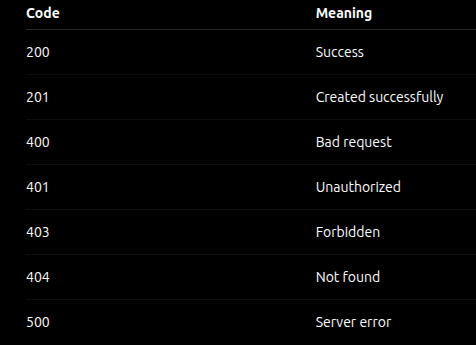

In [3]:
import requests

response = requests.get("https://jsonplaceholder.typicode.com/posts/1")

# Print status code
print(response.status_code)

200


##Authentication (Bearer Tokens, API Keys)

Some APIs are private.

They require proof that you are allowed to use them.

###API Key

**Real-world analogy**

API key = movie ticket.

Without a valid ticket, you cannot enter.



In [4]:
import requests

api_key = "MY_SECRET_KEY"

headers = {
    "x-api-key": api_key
}

response = requests.get(
    "https://example.com/data",
    headers=headers
)

print(response.status_code)

404


###Bearer Token

Bearer token = temporary VIP pass.

Usually used after login.



In [5]:
import requests

token = "abc123token"

headers = {
    "Authorization": f"Bearer {token}"
}

response = requests.get(
    "https://example.com/profile",
    headers=headers
)

print(response.status_code)

404


##Rate Limits, Retries, Exponential Backoff with Tenacity

Servers don’t want users sending too many requests too quickly.

This is called a rate limit.

###Retry Concept

Sometimes APIs fail temporarily because:

* internet issue
* server busy
* timeout

Instead of failing immediately, we retry.

###Exponential Backoff

Wait longer after each failed attempt.

**Example:**

*   Retry 1 → wait 1 sec
*   Retry 2 → wait 2 sec
*    Retry 3 → wait 4 sec

This prevents server overload.

In [8]:
import requests
from tenacity import retry, wait_exponential, stop_after_attempt

# Retry automatically if function fails
@retry(
    wait=wait_exponential(multiplier=1),
    stop=stop_after_attempt(3)
)
def get_data():

    # Send request
    response = requests.get("https://jsonplaceholder.typicode.com/posts/1")

    # Raise error if request failed
    response.raise_for_status()

    # Return JSON data
    return response.json()

# Call function
data = get_data()

# Print result
print(data)

{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}
